# A Linear Soft Sensor for Membrane Fouling — Seawater RO Desalination

A **soft sensor** is a model that stands in for a measurement you don't have. Real
RO plants have flow, pressure, temperature and TDS sensors around the membrane —
but they rarely measure the membrane's *water permeability* directly (it isn't a
physical sensor, it's a fitted model parameter). Yet permeability is exactly what
degrades as the membrane fouls.

The idea here: **learn the clean-membrane relationship between feed conditions and
membrane performance, then watch for when reality stops matching it.**

1. Train a linear regression (with pairwise interaction terms) on the `seawater-ro`
   plant — a flowsheet whose membrane never fouls — to predict **permeate flow**
   and **salt passage** from **feed flow, pressure, temperature and TDS**.
2. Run that trained model, unchanged, across the full time series of
   `seawater-ro-fouled` — a plant whose membrane permeability declines on a slow
   exponential fouling trajectory (see `deployments/WATERTAP/models/seawater-ro-fouled`).
3. The **residual** between predicted and actual output — normalized by the
   training noise — is the anomaly signal. It's built entirely from ordinary
   process measurements; it never sees the membrane's permeability directly.

## Setup
0. Follow the steps in [deployments/WATERTAP/README.md](../../deployments/WATERTAP/README.md) to install requirements.
1. Start the server with the shared config — it now ingests **both** plants by
   default (`watertap-seawater-ro` and `watertap-seawater-ro-fouled`, under
   distinct `wbs:`/`wbsf:` ontology namespaces so they don't collide):
   `acquirium server --config deployments/WATERTAP/scripts/acquirium.toml`
2. Connect:

In [1]:
from acquirium import Acquirium
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

acq = Acquirium(server_url="localhost", server_port=8000, use_ssl=False)
S223 = "http://data.ashrae.org/standard223#"
NAWI = "urn:nawi-water-ontology#"

pl.Config.set_tbl_width_chars(1000)
pl.Config.set_fmt_str_lengths(200)

polars.config.Config

## Pulling feed and permeate data — by meaning, not by plant

Both plants have an equipment node of class `nawi:ReverseOsmosisMembrane` with the
alias `RO` (`wbs:RO` in the healthy plant, `wbsf:RO` in the fouled one) — so a
class-based query like `find_entity(_class="reverse osmosis membrane")` would
return *both* plants' RO units merged into one result. Since we need to keep
"clean training data" and "fouled test data" strictly separate, we query by
**exact URI** instead: same query shape, pointed at one plant's `RO` node at a
time.

Within a plant, the RO unit's inlet is one `ConnectionPoint` carrying the seawater
feed; its outlets are two more, disambiguated by medium — the permeate is
`s223:Fluid-Water`, the retentate/concentrate is `nawi:Water-Brine`. So we walk
`RO -> hasConnectionPoint -> (filter by hasMedium) -> hasProperty` to land on the
sensors we want.

In [2]:
def ro_stream_query(ro_uri: str, medium: str, alias: str):
    """Data observed at the RO unit's connection point carrying `medium`."""
    return (
        acq.find_entity(uri=ro_uri, alias="ro")
           .find_related(_class="ConnectionPoint", alias=f"{alias}_cp",
                         predicates=[S223 + "hasConnectionPoint"], hops=1)
           .find_related(uri=medium, alias=f"{alias}_medium", _from=f"{alias}_cp",
                         predicates=[S223 + "hasMedium"], hops=1)
           .find_data(alias=alias, _from=f"{alias}_cp")
    )


def build_dataset(prefix: str) -> pl.DataFrame:
    """Join feed + permeate streams for one plant (`wbs` or `wbsf`) into one wide frame."""
    ro_uri = f"{prefix}:RO"
    feed_df = ro_stream_query(ro_uri, NAWI + "Water-Seawater", "feed").dataframe(shape="wide", cast_value="float")
    permeate_df = ro_stream_query(ro_uri, S223 + "Fluid-Water", "permeate").dataframe(shape="wide", cast_value="float")

    df = feed_df.join(permeate_df, on="time", how="inner")
    df = df.rename({c: c.split(":")[-1] for c in df.columns if c != "time"})
    df = df.rename({
        "RO-in-flow-mass-water": "feed_flow",
        "RO-in-pressure": "feed_pressure",
        "RO-in-temperature": "feed_temperature",
        "RO-in-flow-mass-tds": "feed_tds",
        "RO-out-flow-mass-water": "permeate_flow",
        "RO-out-flow-mass-tds": "permeate_tds",
    })
    # Salt passage: the fraction of feed salt mass flow that makes it into the
    # permeate (1 - salt rejection) — the standard RO salt-transport metric.
    df = df.with_columns((pl.col("permeate_tds") / pl.col("feed_tds")).alias("salt_passage"))
    return df.drop_nulls().sort("time")


clean = build_dataset("wbs")     # seawater-ro: membrane never fouls
fouled = build_dataset("wbsf")   # seawater-ro-fouled: A declines over the series
print(f"clean:  {clean.shape[0]} samples, {clean['time'].min()} .. {clean['time'].max()}")
print(f"fouled: {fouled.shape[0]} samples, {fouled['time'].min()} .. {fouled['time'].max()}")
clean.select(["feed_flow", "feed_pressure", "feed_temperature", "feed_tds", "permeate_flow", "salt_passage"]).describe()

clean:  4320 samples, 2025-01-01 00:00:00+00:00 .. 2025-01-30 23:50:00+00:00
fouled: 4320 samples, 2025-01-01 00:00:00+00:00 .. 2025-01-30 23:50:00+00:00


statistic,feed_flow,feed_pressure,feed_temperature,feed_tds,permeate_flow,salt_passage
str,f64,f64,f64,f64,f64,f64
"""count""",4320.0,4320.0,4320.0,4320.0,4320.0,4320.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",306.063167,7e6,290.600534,10.366641,140.66583,0.002859
"""std""",18.262433,0.0,0.320232,0.625291,3.640357,0.000215
"""min""",263.348018,7e6,289.48874,8.996445,130.747401,0.002338
"""25%""",289.876854,7e6,290.37688,9.820997,137.66334,0.00267
"""50%""",306.108385,7e6,290.603435,10.371763,140.775337,0.002846
"""75%""",322.11545,7e6,290.818905,10.903187,143.679101,0.003043
"""max""",359.312658,7e6,291.738524,12.066055,150.764884,0.003411


One thing stands out: `feed_pressure` has **zero variance** — this plant runs its
high-pressure pump at a fixed 70 bar setpoint (`P1.control_volume.properties_out[0].pressure`
is fixed in `flowsheet.py`, not one of `generate-values.py`'s varying drivers). We
keep it in the feature set as requested, but a regression can't extract signal
from a constant — its column is exactly its mean in every row, so it folds into
the intercept and contributes nothing beyond that. That's a realistic soft-sensor
caveat, not a bug: real plants often hold one operating variable fixed by control,
and you can't learn its effect from historical data that never varied it.

## The model: OLS with pairwise interaction terms

A "linear model with interaction terms" here means: standardize each feature
(zero mean, unit variance, using **training-set statistics only**), then regress
on the 4 main effects plus all 6 pairwise products
(`feed_flow×feed_pressure`, `feed_flow×feed_temperature`, …) — 11 coefficients
plus an intercept, fit by ordinary least squares. This captures things like "the
pressure sensitivity of permeate flow depends on temperature" without jumping to
a black-box model — everything here is still a closed-form linear fit, just over
an enriched feature set.

In [3]:
FEATURES = ["feed_flow", "feed_pressure", "feed_temperature", "feed_tds"]


class InteractionOLS:
    """OLS on standardized main effects + all pairwise interaction terms."""

    def __init__(self, features):
        self.features = features

    def _design(self, X):
        Xs = (X - self.mean_) / self.std_
        cols = [np.ones(len(Xs))] + [Xs[:, i] for i in range(Xs.shape[1])]
        for i in range(Xs.shape[1]):
            for j in range(i + 1, Xs.shape[1]):
                cols.append(Xs[:, i] * Xs[:, j])
        return np.column_stack(cols)

    def fit(self, X, y):
        self.mean_ = X.mean(axis=0)
        std = X.std(axis=0)
        self.std_ = np.where(std == 0, 1.0, std)  # constant feature -> zero column, not NaN
        D = self._design(X)
        self.coef_, *_ = np.linalg.lstsq(D, y, rcond=None)
        resid = y - D @ self.coef_
        self.train_resid_std_ = resid.std()
        ss_res, ss_tot = (resid ** 2).sum(), ((y - y.mean()) ** 2).sum()
        self.r2_ = 1 - ss_res / ss_tot
        return self

    def predict(self, X):
        return self._design(X) @ self.coef_

## Train on clean-membrane data only

An 80/20 split of the `seawater-ro` series (shuffled, since there's no fouling
trend to leak across a time split here — every sample is equally "clean") checks
that the fit generalizes within the clean regime before we ever point it at the
fouled plant.

In [4]:
rng = np.random.RandomState(0)
n = clean.shape[0]
idx = rng.permutation(n)
split = int(n * 0.8)
train_idx, test_idx = idx[:split], idx[split:]

X_clean = clean.select(FEATURES).to_numpy()
y_flow = clean["permeate_flow"].to_numpy()
y_salt = clean["salt_passage"].to_numpy()

model_flow = InteractionOLS(FEATURES).fit(X_clean[train_idx], y_flow[train_idx])
model_salt = InteractionOLS(FEATURES).fit(X_clean[train_idx], y_salt[train_idx])


def r2(y_true, y_pred):
    return 1 - ((y_true - y_pred) ** 2).sum() / ((y_true - y_true.mean()) ** 2).sum()


print("permeate flow   -- train R2: %.5f   held-out R2: %.5f   train residual std: %.4f kg/s"
      % (model_flow.r2_, r2(y_flow[test_idx], model_flow.predict(X_clean[test_idx])), model_flow.train_resid_std_))
print("salt passage    -- train R2: %.5f   held-out R2: %.5f   train residual std: %.2e"
      % (model_salt.r2_, r2(y_salt[test_idx], model_salt.predict(X_clean[test_idx])), model_salt.train_resid_std_))

permeate flow   -- train R2: 0.99981   held-out R2: 0.99981   train residual std: 0.0494 kg/s
salt passage    -- train R2: 0.99998   held-out R2: 0.99998   train residual std: 1.05e-06


Both targets fit almost perfectly (R² > 0.999) on held-out clean data — expected,
since permeate flow and salt passage really are (near-)deterministic functions of
feed conditions when the membrane itself isn't changing. That tight fit is exactly
what makes the soft sensor useful: the training residual is a good estimate of
"normal" noise, so *any* systematic drift from an unmodeled cause — like fouling —
will stand out clearly against it.

## Score the fouled plant's full time series

`seawater-ro-fouled` starts near-pristine and drifts down a 45-day fouling time
constant. We feed its feed-side measurements into the *same* trained models — they
were never told fouling exists — and look at how far the actual permeate flow and
salt passage fall from what clean-membrane physics would predict.

In [5]:
X_fouled = fouled.select(FEATURES).to_numpy()

pred_flow = model_flow.predict(X_fouled)
pred_salt = model_salt.predict(X_fouled)

resid_flow = fouled["permeate_flow"].to_numpy() - pred_flow
resid_salt = fouled["salt_passage"].to_numpy() - pred_salt

# z-scores in units of the clean-membrane training noise
z_flow = resid_flow / model_flow.train_resid_std_
z_salt = resid_salt / model_salt.train_resid_std_

# Combined anomaly score: a chi-like combination of both z-scores.
anomaly_score = np.sqrt(z_flow ** 2 + z_salt ** 2)

fouled = fouled.with_columns([
    pl.Series("predicted_permeate_flow", pred_flow),
    pl.Series("resid_flow", resid_flow),
    pl.Series("z_flow", z_flow),
    pl.Series("z_salt", z_salt),
    pl.Series("anomaly_score", anomaly_score),
])
fouled.select(["time", "permeate_flow", "predicted_permeate_flow", "z_flow", "z_salt", "anomaly_score"]).head(3)

time,permeate_flow,predicted_permeate_flow,z_flow,z_salt,anomaly_score
"datetime[μs, UTC]",f64,f64,f64,f64,f64
2025-01-01 00:00:00 UTC,138.968712,138.960917,0.157885,-0.718696,0.735834
2025-01-01 00:10:00 UTC,135.906833,135.948661,-0.847249,-1.076816,1.37017
2025-01-01 00:20:00 UTC,134.866033,134.916641,-1.025081,-0.195688,1.043592


## Detecting the onset

A single noisy sample crossing a threshold isn't a detection — we require the
combined score to stay above **3σ for a full hour** (6 consecutive 10-minute
samples) before calling it an anomaly, a simple sustained-exceedance rule.

In [6]:
THRESHOLD = 3.0
SUSTAIN_SAMPLES = 6  # 1 hour at 10-minute sampling

exceeds = anomaly_score > THRESHOLD
sustained = np.convolve(exceeds.astype(int), np.ones(SUSTAIN_SAMPLES, dtype=int), mode="valid") == SUSTAIN_SAMPLES
onset_idx = int(np.argmax(sustained)) if sustained.any() else None

if onset_idx is not None:
    onset_time = fouled["time"][onset_idx]
    elapsed = onset_time - fouled["time"][0]
    print(f"Sustained anomaly detected at {onset_time}  ({elapsed} into the run)")
    print(f"anomaly_score at onset: {anomaly_score[onset_idx]:.1f}   "
          f"(vs. {anomaly_score[:6].mean():.1f} in the first hour, {anomaly_score[-6:].mean():.1f} by the end)")
else:
    print("No sustained anomaly detected.")

Sustained anomaly detected at 2025-01-01 16:20:00+00:00  (16:20:00 into the run)
anomaly_score at onset: 12.8   (vs. 1.6 in the first hour, 515.1 by the end)


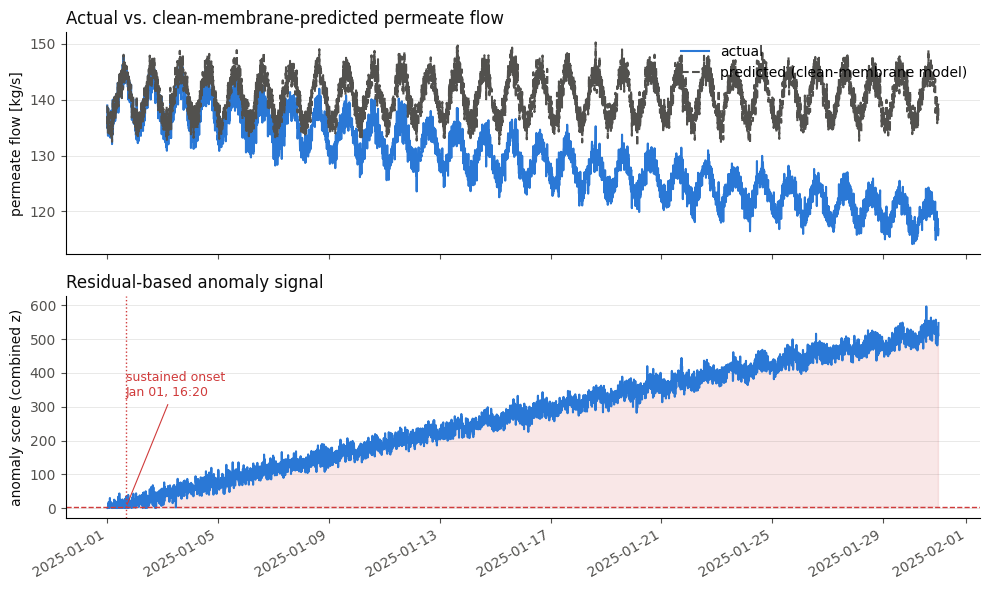

In [7]:
fig, (ax_flow, ax_score) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
BLUE = "#2a78d6"
CRITICAL = "#d03b3b"

t = fouled["time"].to_list()

ax_flow.plot(t, fouled["permeate_flow"], color=BLUE, linewidth=1.5, label="actual")
ax_flow.plot(t, fouled["predicted_permeate_flow"], color=INK_SECONDARY, linewidth=1.5,
             linestyle="--", label="predicted (clean-membrane model)")
ax_flow.set_ylabel("permeate flow [kg/s]", color=INK_PRIMARY)
ax_flow.legend(frameon=False, loc="upper right")
ax_flow.set_title("Actual vs. clean-membrane-predicted permeate flow", color=INK_PRIMARY, loc="left")

ax_score.plot(t, anomaly_score, color=BLUE, linewidth=1.5)
ax_score.axhline(THRESHOLD, color=CRITICAL, linewidth=1, linestyle="--")
ax_score.fill_between(t, THRESHOLD, anomaly_score, where=(anomaly_score > THRESHOLD),
                       color=CRITICAL, alpha=0.12, interpolate=True)
if onset_idx is not None:
    ax_score.axvline(t[onset_idx], color=CRITICAL, linewidth=1, linestyle=":")
    ax_score.annotate(f"sustained onset\n{onset_time:%b %d, %H:%M}",
                       xy=(t[onset_idx], THRESHOLD), xycoords="data",
                       xytext=(t[onset_idx], 0.55), textcoords=("data", "axes fraction"),
                       color=CRITICAL, fontsize=9,
                       arrowprops=dict(arrowstyle="-", color=CRITICAL, linewidth=0.8))
ax_score.set_ylabel("anomaly score (combined z)", color=INK_PRIMARY)
ax_score.set_title("Residual-based anomaly signal", color=INK_PRIMARY, loc="left")

for ax in (ax_flow, ax_score):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", color=INK_SECONDARY, alpha=0.15, linewidth=0.6)
    ax.tick_params(colors=INK_SECONDARY)

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## Validation only: does the anomaly signal actually track fouling?

The soft sensor never sees the membrane's water permeability (`A_comp`) — that's
the point, a real plant wouldn't have it either. But *this* model does, since it's
a WaterTAP simulation, so we can use it purely to check the anomaly signal is
tracking the right underlying cause rather than something spurious.

correlation(anomaly_score, true fouling severity) = 0.9972


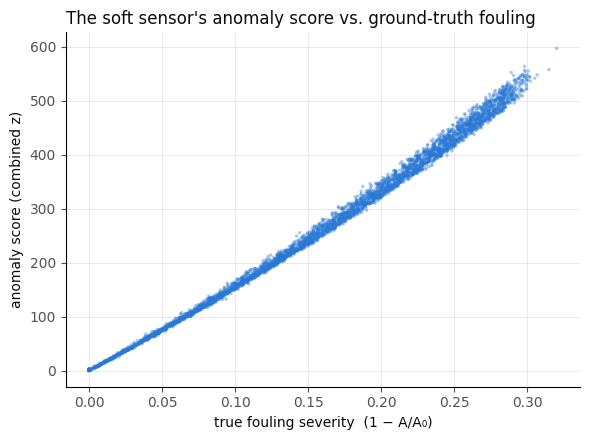

In [8]:
a_comp_df = (
    acq.find_entity(uri="wbsf:RO", alias="ro")
       .find_data(alias="a_comp", _from="ro")
       .dataframe(shape="wide", cast_value="float")
)
a_comp_col = [c for c in a_comp_df.columns if "permeability" in c][0]
a_comp_df = a_comp_df.select(["time", a_comp_col]).rename({a_comp_col: "A_comp"})

fouled_v = fouled.join(a_comp_df, on="time", how="inner")
fouling_severity = 1 - fouled_v["A_comp"].to_numpy() / fouled_v["A_comp"][0]

corr = np.corrcoef(fouled_v["anomaly_score"].to_numpy(), fouling_severity)[0, 1]
print(f"correlation(anomaly_score, true fouling severity) = {corr:.4f}")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(fouling_severity, fouled_v["anomaly_score"], s=6, color=BLUE, alpha=0.4, edgecolors="none")
ax.set_xlabel("true fouling severity  (1 − A/A₀)", color=INK_PRIMARY)
ax.set_ylabel("anomaly score (combined z)", color=INK_PRIMARY)
ax.set_title("The soft sensor's anomaly score vs. ground-truth fouling", color=INK_PRIMARY, loc="left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, color=INK_SECONDARY, alpha=0.15, linewidth=0.6)
ax.tick_params(colors=INK_SECONDARY)
fig.tight_layout()
plt.show()

The anomaly score tracks the true fouling severity almost perfectly (ρ ≈ 0.99),
despite being built from nothing but feed flow, pressure, temperature, TDS and the
resulting permeate flow and salt passage — measurements every RO plant already
has. That's the soft-sensor pattern in one notebook: **a model trained on
known-healthy operation turns "does this match physics?" into a continuously
updated health signal**, without ever needing a sensor for the thing that's
actually failing.

A production version would replace the clean/fouled train/test split with
"before/after the last known cleaning" on real plant data, and would tune the
detection threshold and sustain window against a labeled maintenance history
instead of eyeballing a simulation.